In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_json("C:\\Users\\petru\\Downloads\\companies.jsonl", lines=True)

In [84]:
#print(df.info)
#print(df.describe())
#print(df.head())
#print(df.isnull().sum())
print(df.dtypes)

website                     str
operational_name            str
year_founded              int64
address                  object
employee_count            int64
revenue                   int64
primary_naics            object
description                 str
business_model           object
target_markets           object
core_offerings           object
is_public                  bool
secondary_naics          object
naics_code                  str
industry_name               str
revenue_per_employee    float64
dtype: object


In [64]:
df['website'] = df['website'].fillna('Unknown')
df['secondary_naics'] = df['secondary_naics'].fillna('Unknown')
df['operational_name'] = df['operational_name'].fillna('Unknown')
df['naics_code'] = df['primary_naics'].apply(lambda x: x['code'] if isinstance(x, dict) else x)
naics_year_median = df.groupby('naics_code')['year_founded'].transform('median')
df['year_founded'] = df['year_founded'].fillna(naics_year_median)
df['year_founded'] = df['year_founded'].fillna(df['year_founded'].median())
df['year_founded'] = df['year_founded'].astype(int)
naics_revenue_median = df.groupby('naics_code')['revenue'].transform('median')
df['revenue'] = df['revenue'].fillna(naics_revenue_median)
df['revenue'] = df['revenue'].fillna(df['revenue'].median())
rev_per_emp = (df['revenue'] / df['employee_count']).groupby(df['naics_code']).transform('median')
df['employee_count'] = df['employee_count'].fillna(df['revenue'] / rev_per_emp)
df['employee_count'] = df['employee_count'].fillna(df['employee_count'].median())
df['employee_count'] = df['employee_count'].astype(int)


Completing the datas by filling the missing values with 'unknown' for some categories and the median for the others considering their domain of activity.

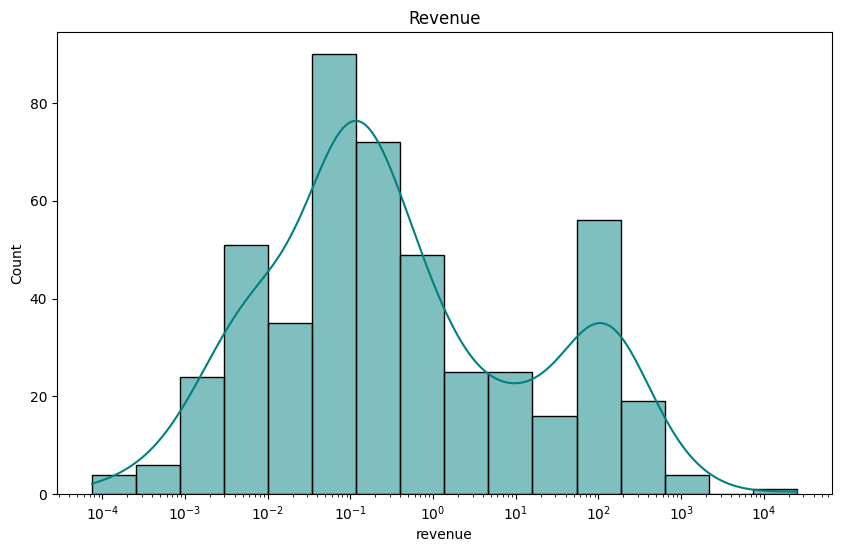

In [67]:
df['revenue'] = df['revenue'].astype(str).str.replace(r'[$, ]', '', regex=True)
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['revenue'] = df['revenue'].astype(int)
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'] / 100_000_000, kde=True, color='teal',log_scale=True)
plt.title('Revenue')
plt.show()

In [82]:
df['description'] = df['description'].astype(str).str.lower().str.strip()
df['industry_name'] = df['primary_naics'].apply(lambda x: x.get('label') if isinstance(x, dict) else 'Unknown')
df['revenue_per_employee'] = df['revenue'] / df['employee_count']
#print(df['industry_name'].value_counts())


A small change in the description category and creating a new label, which was initial inside the naics.

In [85]:

columns = [
    'website', 
    'operational_name', 
    'year_founded', 
    'address', 
    'employee_count', 
    'revenue', 
    'primary_naics', 
    'description', 
    'business_model', 
    'target_markets', 
    'core_offerings', 
    'is_public', 
    'secondary_naics', 
    'naics_code', 
    'industry_name', 
    'revenue_per_employee'
]
df_final = df[columns]
df_final.to_json('companies_data_final.json', orient='records', indent=2)
